# Chapter 3, Example 1: Exact Elimination, Fill-In, and Treewidth

A factorized probability distribution may be small locally but expensive globally. Variable elimination computes the partition function exactly by repeatedly multiplying all factors that contain one selected variable and summing that variable out. The numerical answer does not depend on the elimination order, but the intermediate factor sizes can change dramatically.

This notebook demonstrates:

- exact variable elimination for a binary Ising model on a $3\times3$ grid;
- the induced graph and fill-in edges created by elimination;
- induced width and its connection to treewidth;
- the relation between elimination order and tensor-contraction cost;
- exact agreement with brute-force enumeration.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name == "ch03":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch03").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch03"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
    "lines.linewidth": 2.0,
})

NODE_COLOR = "#2F6B9A"
FACTOR_COLOR = "#555555"

def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


## 1. A binary grid model

Each variable is a spin $s_i\in\{-1,+1\}$. The unnormalized weight is

$$
w(\boldsymbol{s})=\exp\left(\sum_i h_i s_i+\sum_{(i,j)\in E}J_{ij}s_is_j\right).
$$

The grid has only $2^9=512$ configurations, so brute-force enumeration remains possible and provides an independent correctness check.

In [2]:
n_side = 3
n = n_side ** 2
nodes = list(range(n))
coords = {r*n_side+c: (c, -r) for r in range(n_side) for c in range(n_side)}
edges = []
for r in range(n_side):
    for c in range(n_side):
        i = r*n_side+c
        if c+1<n_side: edges.append((i,i+1))
        if r+1<n_side: edges.append((i,i+n_side))

h = np.array([0.18,-0.11,0.07,-0.05,0.13,-0.09,0.06,-0.04,0.10])
J = {tuple(sorted(e)): 0.42 + 0.07*((e[0]+2*e[1])%3-1) for e in edges}

def spin(bit):
    return 2*bit-1

def unary_factor(i):
    return {"scope": (i,), "values": np.array([np.exp(h[i]*spin(b)) for b in (0,1)])}

def pair_factor(i,j):
    values=np.zeros((2,2))
    coupling=J[tuple(sorted((i,j)))]
    for bi,bj in product((0,1),repeat=2):
        values[bi,bj]=np.exp(coupling*spin(bi)*spin(bj))
    return {"scope": (i,j), "values": values}

factors=[unary_factor(i) for i in nodes]+[pair_factor(i,j) for i,j in edges]
print(f"Variables: {n}; edges: {len(edges)}; configurations: {2**n}")

Variables: 9; edges: 12; configurations: 512


## 2. Exact elimination as local tensor contraction

A factor is represented by a scope and a table. To eliminate variable $x$, we multiply every factor whose scope contains $x$, then sum the product over $x$. The resulting factor is defined on the union of the neighboring scopes with $x$ removed.

The number of variables in this new scope is the local separator size. For binary variables, a factor with scope size $k$ contains $2^k$ entries.

In [3]:
def align_values(factor, target_scope):
    scope=factor["scope"]
    values=factor["values"]
    present=[v for v in target_scope if v in scope]
    perm=[scope.index(v) for v in present]
    if len(scope)>1 and perm != list(range(len(scope))):
        values=np.transpose(values,perm)
    shape=[2 if v in scope else 1 for v in target_scope]
    return values.reshape(shape)

def multiply_factors(selected):
    union=[]
    for f in selected:
        for v in f["scope"]:
            if v not in union: union.append(v)
    values=np.ones([2]*len(union)) if union else np.array(1.0)
    for f in selected:
        values=values*align_values(f,tuple(union))
    return {"scope":tuple(union),"values":values}

def eliminate_variable(factors, variable):
    touched=[f for f in factors if variable in f["scope"]]
    untouched=[f for f in factors if variable not in f["scope"]]
    product_factor=multiply_factors(touched)
    axis=product_factor["scope"].index(variable)
    new_scope=tuple(v for v in product_factor["scope"] if v!=variable)
    new_values=product_factor["values"].sum(axis=axis)
    new_factor={"scope":new_scope,"values":new_values}
    return untouched+[new_factor], new_scope

def variable_elimination(factors, order):
    working=[{"scope":f["scope"],"values":f["values"].copy()} for f in factors]
    profile=[]
    for v in order:
        working,new_scope=eliminate_variable(working,v)
        profile.append({"variable":v,"separator_size":len(new_scope),"table_entries":2**len(new_scope)})
    result=multiply_factors(working)["values"].sum()
    return float(result),pd.DataFrame(profile)

def brute_force_Z():
    total=0.0
    for bits in product((0,1),repeat=n):
        spins=np.array([spin(b) for b in bits])
        exponent=h@spins+sum(J[tuple(sorted((i,j)))]*spins[i]*spins[j] for i,j in edges)
        total+=np.exp(exponent)
    return total

Z_brute=brute_force_Z()
print(f"Brute-force Z = {Z_brute:.10f}")

Brute-force Z = 1675.3496378916


## 3. Elimination orders and induced width

When a variable is eliminated, all of its current neighbors become mutually connected. These new edges are called fill-in edges. The largest number of surviving neighbors encountered along an order is its induced width. The minimum possible induced width over all orders is the graph's treewidth. Computing treewidth exactly is generally difficult, so practical algorithms use heuristics such as minimum degree or minimum fill.

In [4]:
def induced_profile(graph,order):
    g=graph.copy(); profile=[]; fill_edges=[]
    for v in order:
        nbrs=list(g.neighbors(v))
        profile.append(len(nbrs))
        for a,b in product(nbrs,nbrs):
            if a<b and not g.has_edge(a,b):
                g.add_edge(a,b); fill_edges.append((a,b))
        g.remove_node(v)
    return profile,fill_edges

def min_fill_order(graph):
    g=graph.copy(); order=[]
    while g.nodes:
        def score(v):
            nbrs=list(g.neighbors(v))
            missing=sum(1 for i,a in enumerate(nbrs) for b in nbrs[i+1:] if not g.has_edge(a,b))
            return (missing,len(nbrs),v)
        v=min(g.nodes,key=score)
        nbrs=list(g.neighbors(v))
        for i,a in enumerate(nbrs):
            for b in nbrs[i+1:]: g.add_edge(a,b)
        g.remove_node(v); order.append(v)
    return order

grid=nx.Graph(edges)
row_major=list(range(n))
center_first=[4,1,3,5,7,0,2,6,8]
min_fill=min_fill_order(grid)
orders={"Row-major":row_major,"Center-first":center_first,"Minimum-fill heuristic":min_fill}
rows=[]
profiles={}; elimination_profiles={}
for name,order in orders.items():
    graph_profile,_=induced_profile(grid,order)
    Z,table=variable_elimination(factors,order)
    profiles[name]=graph_profile; elimination_profiles[name]=table
    rows.append({"order":name,"induced width":max(graph_profile),"largest table":int(table["table_entries"].max()),"relative error":abs(Z-Z_brute)/Z_brute})
summary=pd.DataFrame(rows)
display(summary)
for name,order in orders.items(): print(name,order)
assert summary["relative error"].max()<1e-12

,order,induced width,largest table,relative error
0,Row-major,3,8,2.714343e-16
1,Center-first,5,32,1.357171e-16
2,Minimum-fill heuristic,3,8,2.714343e-16


Row-major [0, 1, 2, 3, 4, 5, 6, 7, 8]
Center-first [4, 1, 3, 5, 7, 0, 2, 6, 8]
Minimum-fill heuristic [0, 2, 6, 8, 1, 3, 4, 5, 7]


Saved: figs/ch03_01_grid_elimination_orders.pdf


Saved: figs/ch03_01_grid_elimination_orders.png


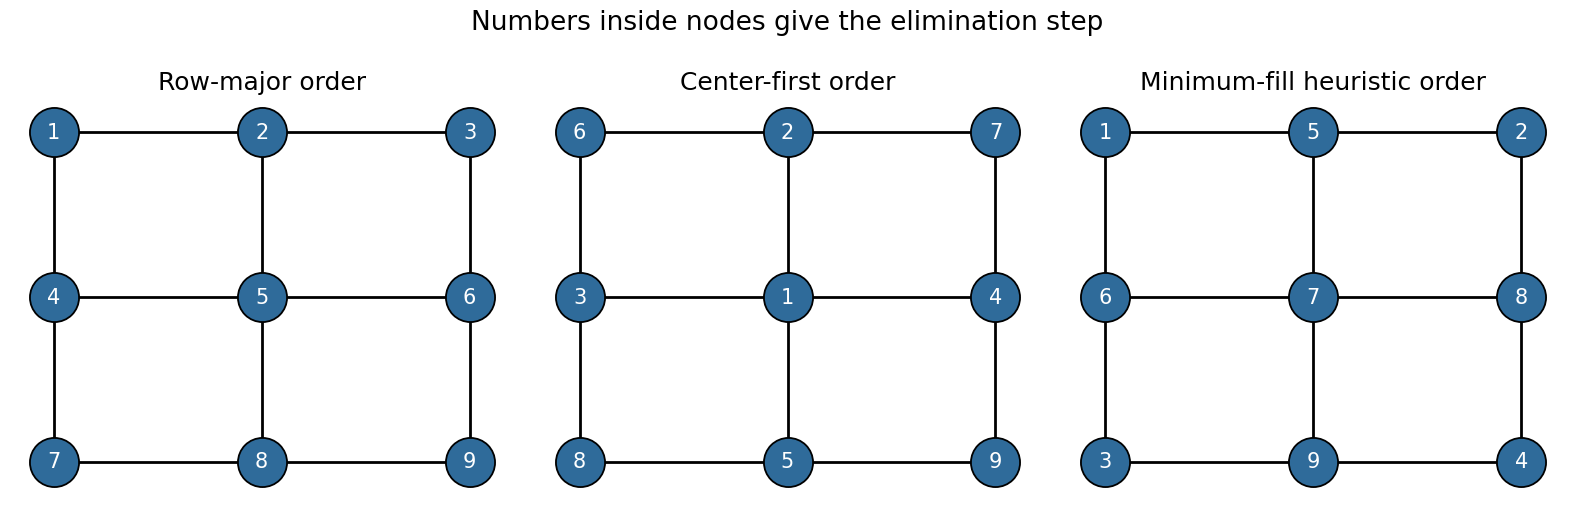

Saved: figs/ch03_01_induced_width_profiles.pdf
Saved: figs/ch03_01_induced_width_profiles.png


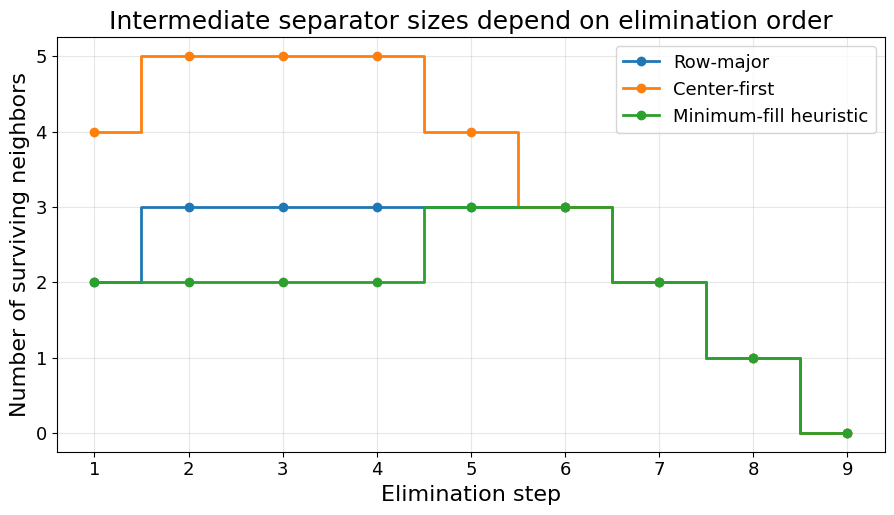

In [5]:
fig,axes=plt.subplots(1,3,figsize=(16,5.2))
for ax,(name,order) in zip(axes,orders.items()):
    labels={v:str(order.index(v)+1) for v in nodes}
    nx.draw_networkx_edges(grid,coords,width=2.0,ax=ax)
    nx.draw_networkx_nodes(grid,coords,node_size=1250,node_color=NODE_COLOR,edgecolors="black",linewidths=1.3,ax=ax)
    nx.draw_networkx_labels(grid,coords,labels=labels,font_size=15,font_color="white",ax=ax)
    ax.set_title(name+" order")
    ax.axis("off")
fig.suptitle("Numbers inside nodes give the elimination step")
fig.tight_layout()
save_figure(fig,"ch03_01_grid_elimination_orders")
plt.show()

fig,ax=plt.subplots(figsize=(9.2,5.4))
for name,profile in profiles.items():
    ax.step(np.arange(1,n+1),profile,where="mid",marker="o",label=name)
ax.set_xlabel("Elimination step")
ax.set_ylabel("Number of surviving neighbors")
ax.set_title("Intermediate separator sizes depend on elimination order")
ax.set_xticks(range(1,n+1))
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); save_figure(fig,"ch03_01_induced_width_profiles"); plt.show()

## 4. Interpretation

All orders return the same exact partition function. The computational burden is controlled by the largest intermediate factor, not by the number of original factors alone. This is the same ordering problem that appears in sparse matrix factorization and tensor-network contraction.

The notebook uses binary variables, but for alphabet size $q$ a separator of size $k$ creates a table with $q^k$ entries.

## Exercises

1. Replace the $3\times3$ grid by a chain of nine variables. Compare the induced widths of several orders. Which orders preserve width one?
2. Add one diagonal edge to every grid cell and repeat the order comparison.
3. Implement the minimum-degree heuristic and compare it with minimum fill.
4. Replace the sum in elimination by a maximum. Verify the resulting MAP value by enumeration.
5. Treat every factor table as a tensor and describe each elimination step as a tensor contraction followed by an index sum.